
# Image denoising using kernel PCA

This example shows how to use :class:`~sklearn.decomposition.KernelPCA` to
denoise images. In short, we take advantage of the approximation function
learned during `fit` to reconstruct the original image.

We will compare the results with an exact reconstruction using
:class:`~sklearn.decomposition.PCA`.

We will use USPS digits dataset to reproduce presented in Sect. 4 of [1]_.

.. rubric:: References

.. [1] [Bakır, Gökhan H., Jason Weston, and Bernhard Schölkopf.
    "Learning to find pre-images."
    Advances in neural information processing systems 16 (2004): 449-456.](https://papers.nips.cc/paper/2003/file/ac1ad983e08ad3304a97e147f522747e-Paper.pdf)


In [1]:
# Authors: The scikit-learn developers
# SPDX-License-Identifier: BSD-3-Clause

## Load the dataset via OpenML

The USPS digits datasets is available in OpenML. We use
:func:`~sklearn.datasets.fetch_openml` to get this dataset. In addition, we
normalize the dataset such that all pixel values are in the range (0, 1).



In [2]:
import numpy as np

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

X, y = fetch_openml(data_id=41082, as_frame=False, return_X_y=True)
X = MinMaxScaler().fit_transform(X)

The idea will be to learn a PCA basis (with and without a kernel) on
noisy images and then use these models to reconstruct and denoise these
images.

Thus, we split our dataset into a training and testing set composed of 1,000
samples for the training and 100 samples for testing. These images are
noise-free and we will use them to evaluate the efficiency of the denoising
approaches. In addition, we create a copy of the original dataset and add a
Gaussian noise.

The idea of this application, is to show that we can denoise corrupted images
by learning a PCA basis on some uncorrupted images. We will use both a PCA
and a kernel-based PCA to solve this problem.



In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, random_state=0, train_size=1_000, test_size=100
)

rng = np.random.RandomState(0)
noise = rng.normal(scale=0.25, size=X_test.shape)
X_test_noisy = X_test + noise

noise = rng.normal(scale=0.25, size=X_train.shape)
X_train_noisy = X_train + noise

In addition, we will create a helper function to qualitatively assess the
image reconstruction by plotting the test images.



In [4]:
import matplotlib.pyplot as plt


def plot_digits(X, title):
    """Small helper function to plot 100 digits."""
    fig, axs = plt.subplots(nrows=10, ncols=10, figsize=(8, 8))
    for img, ax in zip(X, axs.ravel()):
        ax.imshow(img.reshape((16, 16)), cmap="Greys")
        ax.axis("off")
    fig.suptitle(title, fontsize=24)

In addition, we will use the mean squared error (MSE) to quantitatively
assess the image reconstruction.

Let's first have a look to see the difference between noise-free and noisy
images. We will check the test set in this regard.



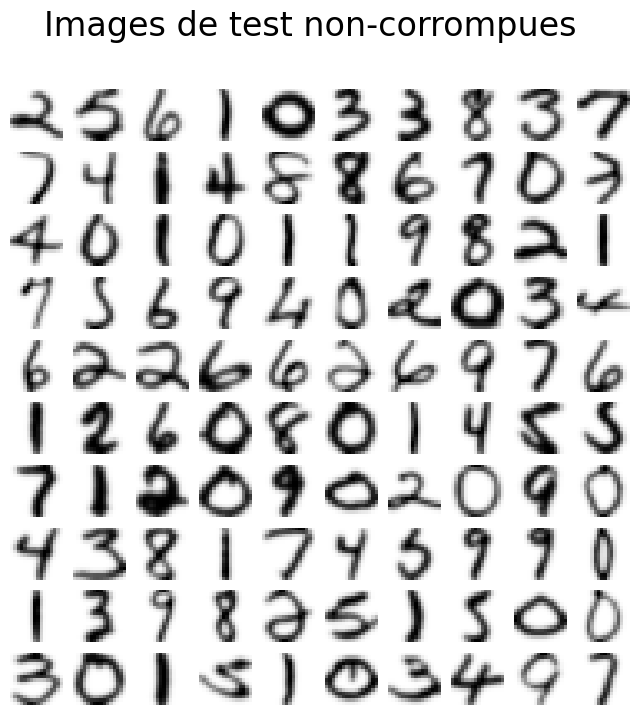

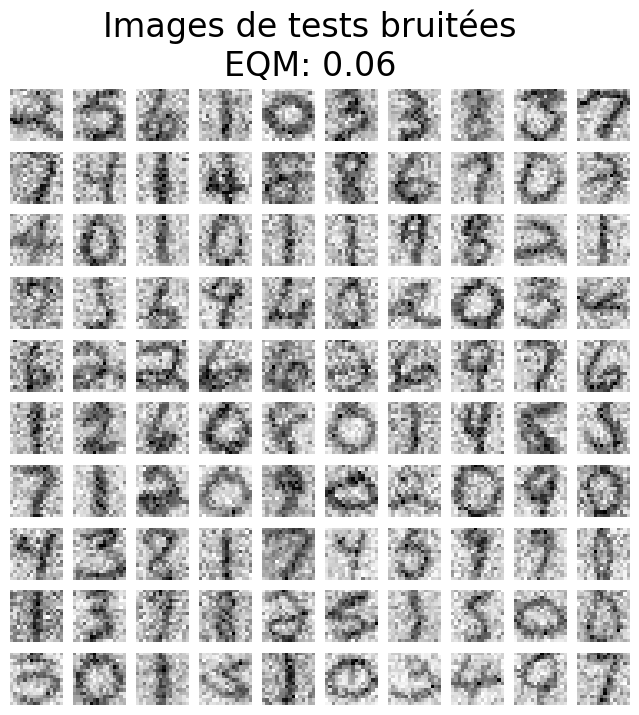

In [5]:
plot_digits(X_test, "Images de test non-corrompues")
plot_digits(
    X_test_noisy, f"Images de tests bruitées\nEQM: {np.mean((X_test - X_test_noisy) ** 2):.2f}"
)

## Learn the `PCA` basis

We can now learn our PCA basis using both a linear PCA and a kernel PCA that
uses a radial basis function (RBF) kernel.



In [6]:
from sklearn.decomposition import PCA, KernelPCA

pca = PCA(n_components=32, random_state=42)
kernel_pca = KernelPCA(
    n_components=400,
    kernel="rbf",
    gamma=1e-3,
    fit_inverse_transform=True,
    alpha=5e-3,
    random_state=42,
)

pca.fit(X_train_noisy)
_ = kernel_pca.fit(X_train_noisy)

## Reconstruct and denoise test images

Now, we can transform and reconstruct the noisy test set. Since we used less
components than the number of original features, we will get an approximation
of the original set. Indeed, by dropping the components explaining variance
in PCA the least, we hope to remove noise. Similar thinking happens in kernel
PCA; however, we expect a better reconstruction because we use a non-linear
kernel to learn the PCA basis and a kernel ridge to learn the mapping
function.



In [7]:
X_reconstructed_kernel_pca = kernel_pca.inverse_transform(
    kernel_pca.transform(X_test_noisy)
)
X_reconstructed_pca = pca.inverse_transform(pca.transform(X_test_noisy))

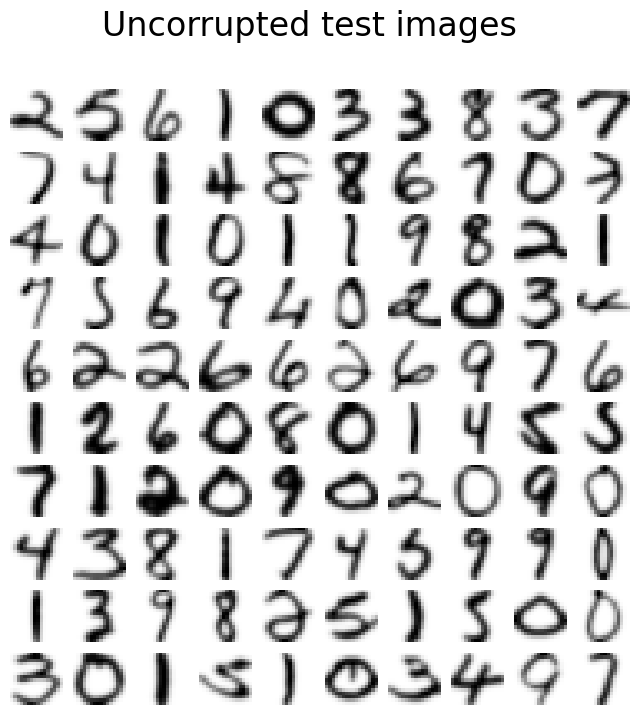

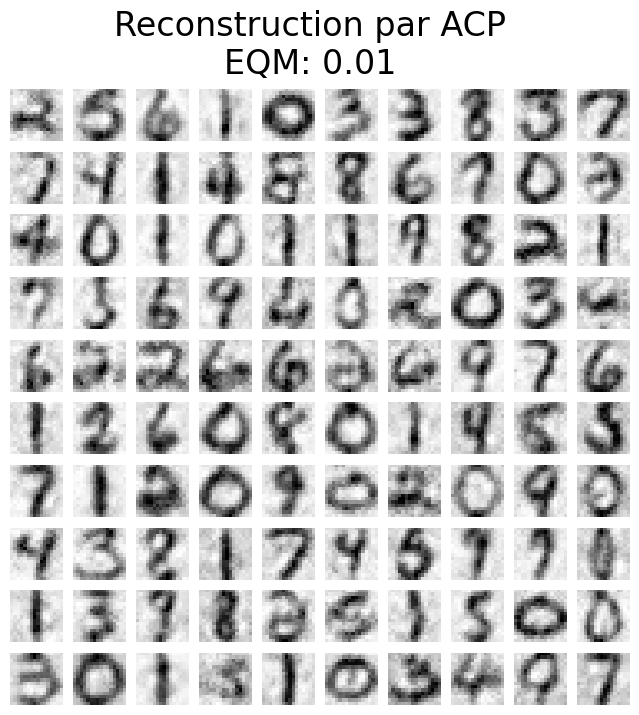

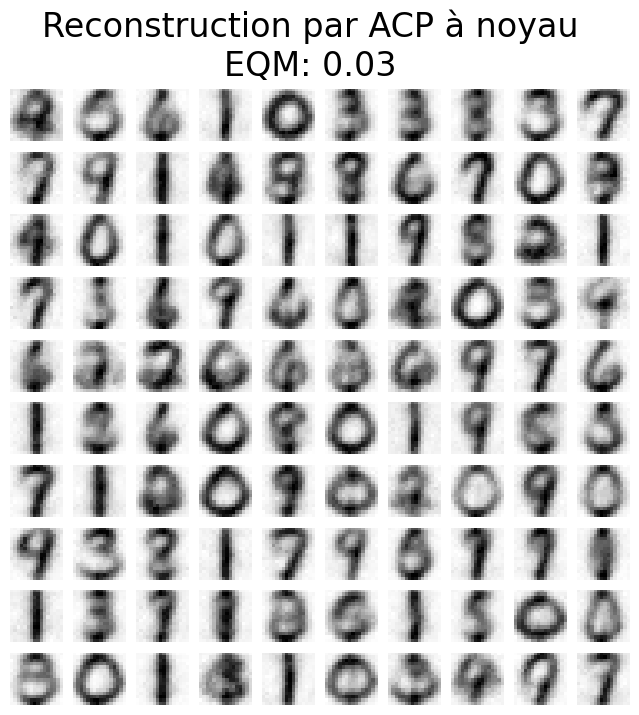

In [8]:
plot_digits(X_test, "Uncorrupted test images")
plot_digits(
    X_reconstructed_pca,
    f"Reconstruction par ACP\nEQM: {np.mean((X_test - X_reconstructed_pca) ** 2):.2f}",
)
plot_digits(
    X_reconstructed_kernel_pca,
    (
        "Reconstruction par ACP à noyau\n"
        f"EQM: {np.mean((X_test - X_reconstructed_kernel_pca) ** 2):.2f}"
    ),
)

PCA has a lower MSE than kernel PCA. However, the qualitative analysis might
not favor PCA instead of kernel PCA. We observe that kernel PCA is able to
remove background noise and provide a smoother image.

However, it should be noted that the results of the denoising with kernel PCA
will depend of the parameters `n_components`, `gamma`, and `alpha`.



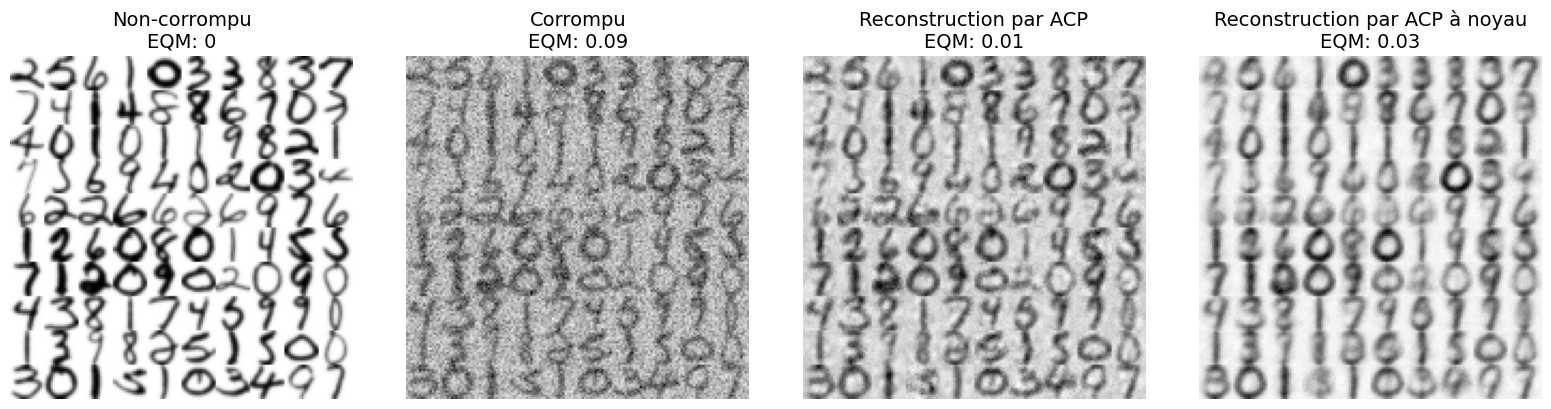

In [57]:
# Création d'une mosaïque pour afficher 100 images (10x10)
def make_montage(X, n_rows=10, n_cols=10, img_shape=(16, 16)):
    """Assemble les images en une grande mosaïque."""
    montage = np.zeros((n_rows * img_shape[0], n_cols * img_shape[1]))
    for i in range(n_rows):
        for j in range(n_cols):
            idx = i * n_cols + j
            img = X[idx].reshape(img_shape)
            montage[i * img_shape[0]:(i + 1) * img_shape[0],
                    j * img_shape[1]:(j + 1) * img_shape[1]] = img
    return montage

# Création de la figure avec 4 sous‑figures côte à côte
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# Mosaïques pour chaque ensemble
montage_original = make_montage(X_test)
montage_noisy = make_montage(X_test_noisy)
montage_pca = make_montage(X_reconstructed_pca)
montage_kpca = make_montage(X_reconstructed_kernel_pca)

# Titres en français
titles = ["Non-corrompu\nEQM: 0", "Corrompu\nEQM: 0.09" , f"Reconstruction par ACP\nEQM: {np.mean((X_test - X_reconstructed_pca) ** 2):.2f}", "Reconstruction par ACP à noyau\n"
        f"EQM: {np.mean((X_test - X_reconstructed_kernel_pca) ** 2):.2f}"]
montages = [montage_original, montage_noisy, montage_pca, montage_kpca]

# Affichage
for ax, mont, title in zip(axes, montages, titles):
    ax.imshow(mont, cmap="Greys")
    ax.set_title(title, fontsize=14)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [10]:
from sklearn.datasets import fetch_olivetti_faces
from sklearn.decomposition import PCA, KernelPCA

In [14]:
# On charge les données de visages 
faces = fetch_olivetti_faces(shuffle=True, random_state=42)
X = faces.data
y = faces.target

In [15]:
# On divise données en train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=100, random_state=0, stratify=y
)

In [16]:
# On sélectionne les 2 premiers visages du test
n_test = 2
X_test = X_test[:n_test+3]
y_test = y_test[:n_test+4]

In [17]:
# Ajouter du bruit
rng = np.random.RandomState(0)
noise_std = 0.2
X_train_noisy = X_train + rng.normal(scale=noise_std, size=X_train.shape)
X_test_noisy  = X_test  + rng.normal(scale=noise_std, size=X_test.shape)


In [18]:
# Clipping optionnel
X_train_noisy = np.clip(X_train_noisy, 0, 1)
X_test_noisy  = np.clip(X_test_noisy, 0, 1)


In [19]:
# PCA linéaire
pca = PCA(n_components=64, random_state=42)
pca.fit(X_train_noisy)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",64
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD

In [20]:
# Kernel PCA avec inverse
kpca = KernelPCA(
    n_components=200,
    kernel='rbf',
    gamma=0.0005,
    fit_inverse_transform=True,
    alpha=0.0001,
    random_state=42
)
kpca.fit(X_train_noisy)

,"n_components n_components: int, default=NoneNumber of components. If None, all non-zero components are kept.",200
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'cosine', 'precomputed'} or callable, default='linear'Kernel used for PCA.",'rbf'
,"gamma gamma: float, default=NoneKernel coefficient for rbf, poly and sigmoid kernels. Ignored by otherkernels. If ``gamma`` is ``None``, then it is set to ``1/n_features``.",0.0005
,"degree degree: float, default=3Degree for poly kernels. Ignored by other kernels.",3
,"coef0 coef0: float, default=1Independent term in poly and sigmoid kernels.Ignored by other kernels.",1
,"kernel_params kernel_params: dict, default=NoneParameters (keyword arguments) andvalues for kernel passed as callable object.Ignored by other kernels.",None
,"alpha alpha: float, default=1.0Hyperparameter of the ridge regression that learns theinverse transform (when fit_inverse_transform=True).",0.0001
,"fit_inverse_transform fit_inverse_transform: bool, default=FalseLearn the inverse transform for non-precomputed kernels(i.e. learn to find the pre-image of a point). This method is basedon [2]_.",True
,"eigen_solver eigen_solver: {'auto', 'dense', 'arpack', 'randomized'}, default='auto'Select eigensolver to use. If `n_components` is muchless than the number of training samples, randomized (or arpack to asmaller extent) may be more efficient than the dense eigensolver.Randomized SVD is performed according to the method of Halko et al[3]_.auto : the solver is selected by a default policy based on n_samples (the number of training samples) and `n_components`: if the number of components to extract is less than 10 (strict) and the number of samples is more than 200 (strict), the 'arpack' method is enabled. Otherwise the exact full eigenvalue decomposition is computed and optionally truncated afterwards ('dense' method).dense : run exact full eigenvalue decomposition calling the standard LAPACK solver via `scipy.linalg.eigh`, and select the components by postprocessingarpack : run SVD truncated to n_components calling ARPACK solver using `scipy.sparse.linalg.eigsh`. It requires strictly 0 < n_components < n_samplesrandomized : run randomized SVD by the method of Halko et al. [3]_. The current implementation selects eigenvalues based on their module; therefore using this method can lead to unexpected results if the kernel is not positive semi-definite. See also [4]_... versionchanged:: 1.0 `'randomized'` was added.",'auto'
,"tol tol: float, default=0Convergence tolerance for arpack.If 0, optimal value will be chosen by arpack.",0
,"max_iter max_iter: int, default=NoneMaximum number of iterations for arpack.If None, optimal value will be chosen by arpack.",None


In [21]:
# Reconstruction
X_test_pca = pca.inverse_transform(pca.transform(X_test_noisy))
X_test_kpca = kpca.inverse_transform(kpca.transform(X_test_noisy))

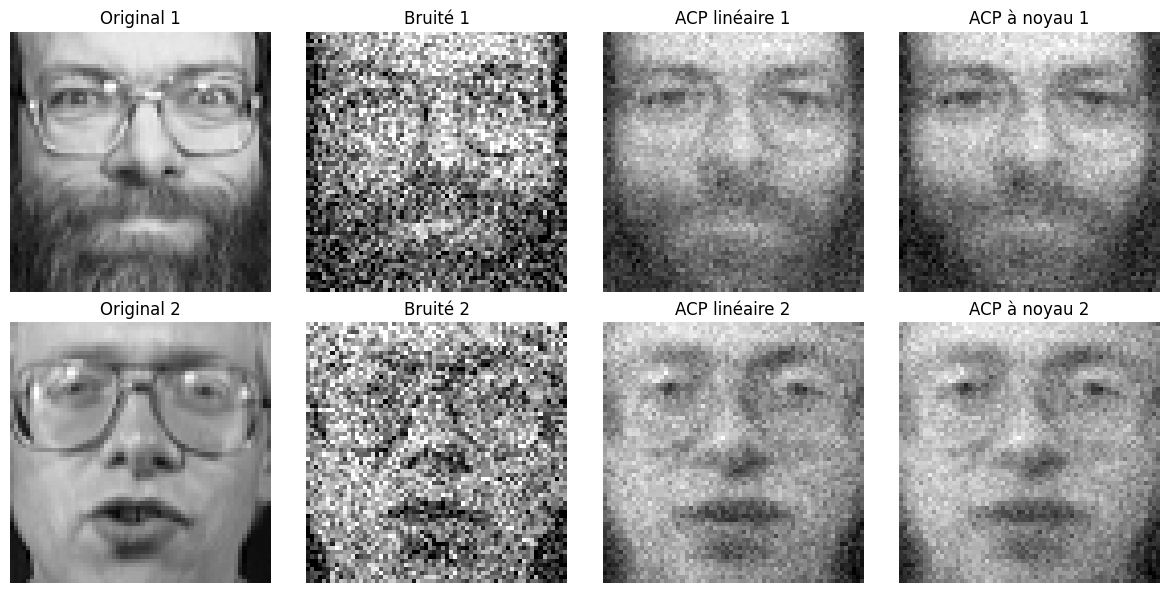

MSE par image (original vs reconstruction) :
Image 1 : PCA MSE = 0.0080, Kernel PCA MSE = 0.0082
Image 2 : PCA MSE = 0.0073, Kernel PCA MSE = 0.0074


In [22]:
# Visualisation des 2 visages
fig, axes = plt.subplots(n_test, 4, figsize=(12, 6))
for i in range(n_test):
    # Original
    axes[i, 0].imshow(X_test[i].reshape(64, 64), cmap='gray')
    axes[i, 0].set_title(f"Original {i+1}")
    axes[i, 0].axis('off')
    
    # Bruité
    axes[i, 1].imshow(X_test_noisy[i].reshape(64, 64), cmap='gray')
    axes[i, 1].set_title(f"Bruité {i+1}")
    axes[i, 1].axis('off')
    
    # PCA
    axes[i, 2].imshow(X_test_pca[i].reshape(64, 64), cmap='gray')
    axes[i, 2].set_title(f"ACP linéaire {i+1}")
    axes[i, 2].axis('off')
    
    # Kernel PCA
    axes[i, 3].imshow(X_test_kpca[i].reshape(64, 64), cmap='gray')
    axes[i, 3].set_title(f"ACP à noyau {i+1}")
    axes[i, 3].axis('off')

plt.tight_layout()
plt.show()

# Calcul et affichage des MSE pour chaque image
print("MSE par image (original vs reconstruction) :")
for i in range(n_test):
    mse_pca = np.mean((X_test[i] - X_test_pca[i])**2)
    mse_kpca = np.mean((X_test[i] - X_test_kpca[i])**2)
    print(f"Image {i+1} : PCA MSE = {mse_pca:.4f}, Kernel PCA MSE = {mse_kpca:.4f}")

In [23]:
X_train_part, X_val, y_train_part, y_val = train_test_split(
    X_train_noisy, X_train, test_size=0.2, random_state=42
)

# Grille de paramètres
gamma_values = [1e-4, 5e-4, 1e-3, 5e-3, 1e-2]
alpha_values = [1e-4, 1e-3, 5e-3, 1e-2, 1e-1]

best_mse = np.inf
best_params = {}

for gamma in gamma_values:
    for alpha in alpha_values:
        kpca = KernelPCA(
            n_components=200,
            kernel='rbf',
            gamma=gamma,
            fit_inverse_transform=True,
            alpha=alpha,
            random_state=42
        )
        kpca.fit(X_train_part)
        X_val_reconstructed = kpca.inverse_transform(kpca.transform(X_val))
        mse = np.mean((y_val - X_val_reconstructed) ** 2)
        if mse < best_mse:
            best_mse = mse
            best_params = {'gamma': gamma, 'alpha': alpha}

print(f"Meilleurs paramètres : {best_params}, MSE = {best_mse:.6f}")

Meilleurs paramètres : {'gamma': 0.0005, 'alpha': 0.0001}, MSE = 0.007522


Meilleurs paramètres : {'gamma': 0.0005, 'alpha': 0.0001}, MSE sur validation = 0.007506


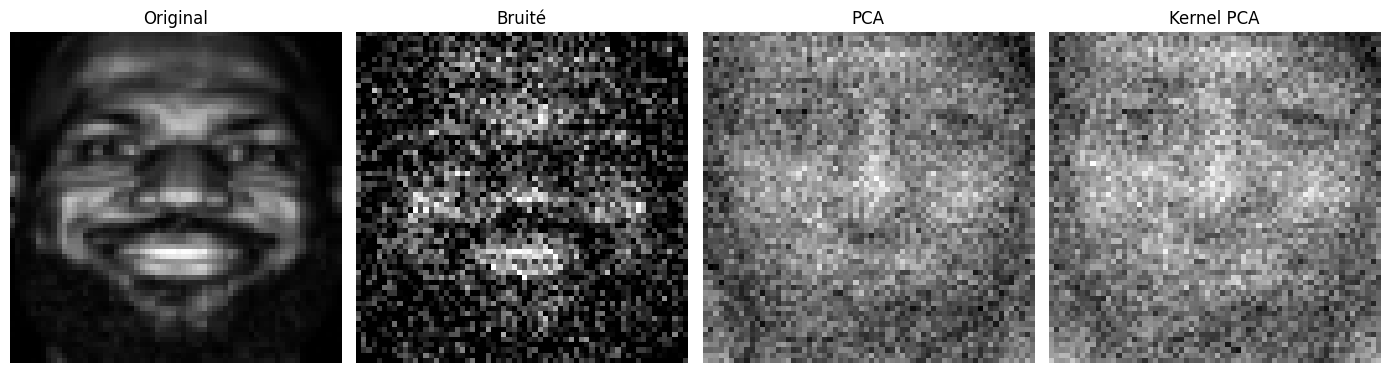

MSE - PCA : 0.0270
MSE - Kernel PCA : 0.0372


In [24]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA, KernelPCA
from PIL import Image

# ===============================
# 1. Charger les visages Olivetti
# ===============================
faces = fetch_olivetti_faces(shuffle=True, random_state=42)
X = faces.data          # (400, 4096)
y = faces.target

# ===============================
# 2. Diviser en train / validation / test
# ===============================
# D'abord séparer train (300) et test (100)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=100, random_state=0, stratify=y
)

# Puis diviser train en train (240) et validation (60)
X_train_part, X_val, y_train_part, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

# ===============================
# 3. Ajouter du bruit gaussien
# ===============================
rng = np.random.RandomState(0)
noise_std = 0.2

X_train_part_noisy = X_train_part + rng.normal(scale=noise_std, size=X_train_part.shape)
X_val_noisy        = X_val        + rng.normal(scale=noise_std, size=X_val.shape)
X_test_noisy       = X_test       + rng.normal(scale=noise_std, size=X_test.shape)

# Clipping pour rester dans [0,1] (optionnel mais conseillé)
X_train_part_noisy = np.clip(X_train_part_noisy, 0, 1)
X_val_noisy        = np.clip(X_val_noisy, 0, 1)
X_test_noisy       = np.clip(X_test_noisy, 0, 1)

# ===============================
# 4. Recherche des meilleurs paramètres pour Kernel PCA
# ===============================
gamma_values = [1e-4, 5e-4, 1e-3, 5e-3, 1e-2]
alpha_values = [1e-4, 1e-3, 5e-3, 1e-2, 1e-1]

best_mse = np.inf
best_params = {}

for gamma in gamma_values:
    for alpha in alpha_values:
        kpca = KernelPCA(
            n_components=200,
            kernel='rbf',
            gamma=gamma,
            fit_inverse_transform=True,
            alpha=alpha,
            random_state=42
        )
        kpca.fit(X_train_part_noisy)
        X_val_reconstructed = kpca.inverse_transform(kpca.transform(X_val_noisy))
        mse = np.mean((X_val - X_val_reconstructed) ** 2)
        if mse < best_mse:
            best_mse = mse
            best_params = {'gamma': gamma, 'alpha': alpha}

print(f"Meilleurs paramètres : {best_params}, MSE sur validation = {best_mse:.6f}")

# ===============================
# 5. Entraînement final avec les meilleurs paramètres
# ===============================
kpca_best = KernelPCA(
    n_components=200,
    kernel='rbf',
    gamma=best_params['gamma'],
    fit_inverse_transform=True,
    alpha=best_params['alpha'],
    random_state=42
)
kpca_best.fit(X_train_noisy)  # on utilise tout le train (300 images) pour l'entraînement final

# PCA linéaire pour comparaison
pca = PCA(n_components=64, random_state=42)
pca.fit(X_train_noisy)

# ===============================
# 6. Charger votre image personnelle (smatou)
# ===============================
# Remplacez 'chemin/vers/votre/image.jpg' par le chemin réel
image_path = "lbj2.jpg"
pil_img = Image.open(image_path).convert('L')
pil_img = pil_img.resize((64, 64))
img_smatou = np.array(pil_img) / 255.0
img_smatou = img_smatou.reshape(1, -1)

# Ajouter du bruit (même niveau que pour les visages)
img_smatou_noisy = img_smatou + rng.normal(scale=noise_std, size=img_smatou.shape)
img_smatou_noisy = np.clip(img_smatou_noisy, 0, 1)

# ===============================
# 7. Reconstruction
# ===============================
img_smatou_pca = pca.inverse_transform(pca.transform(img_smatou_noisy))
img_smatou_kpca = kpca_best.inverse_transform(kpca_best.transform(img_smatou_noisy))

# ===============================
# 8. Visualisation
# ===============================
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
images = [img_smatou, img_smatou_noisy, img_smatou_pca, img_smatou_kpca]
titles = ['Original', 'Bruité', 'PCA', 'Kernel PCA']

for ax, im, title in zip(axes, images, titles):
    ax.imshow(im.reshape(64, 64), cmap='gray')
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.show()

# Affichage des MSE pour l'image smatou
mse_pca_smatou = np.mean((img_smatou - img_smatou_pca) ** 2)
mse_kpca_smatou = np.mean((img_smatou - img_smatou_kpca) ** 2)
print(f"MSE - PCA : {mse_pca_smatou:.4f}")
print(f"MSE - Kernel PCA : {mse_kpca_smatou:.4f}")

In [25]:
from PIL import Image
import numpy as np

# Charger l'image (remplacez par le chemin de votre fichier)
img = Image.open('gsp2face.jpg').convert('L')  # 'L' = niveaux de gris
img = img.resize((64, 64))                      # redimensionner

# Convertir en tableau numpy et normaliser entre 0 et 1
img_array = np.array(img) / 255.0

# Aplatir en vecteur (1, 4096)
img_vector = img_array.reshape(1, -1)

In [26]:
# Après avoir chargé X_test et X_test_noisy (comme dans le code précédent)
X_test[0] = img_vector[0]           # l'image originale (non bruitée) – à garder pour référence
X_test_noisy[0] = img_vector[0] + rng.normal(scale=noise_std, size=img_vector[0].shape)

In [27]:
X_test_smatou = img_vector
# Ajouter du bruit
X_test_smatou_noisy = X_test_smatou + rng.normal(scale=noise_std, size=X_test_smatou.shape)
X_test_smatou_noisy = np.clip(X_test_smatou_noisy, 0, 1)

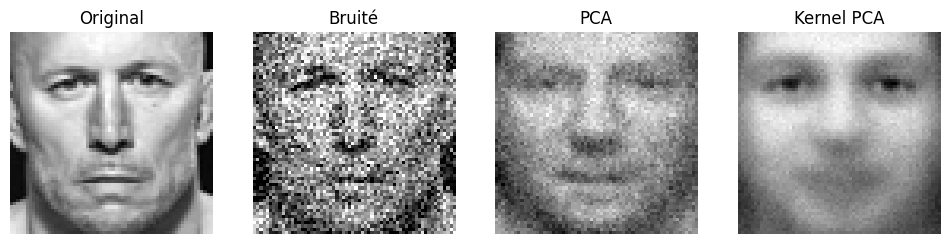

In [28]:
# Reconstruction
X_smatou_pca = pca.inverse_transform(pca.transform(X_test_smatou_noisy))
X_smatou_kpca = kpca.inverse_transform(kpca.transform(X_test_smatou_noisy))

# Affichage
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
axes[0].imshow(X_test_smatou.reshape(64, 64), cmap='gray')
axes[0].set_title('Original')
axes[1].imshow(X_test_smatou_noisy.reshape(64, 64), cmap='gray')
axes[1].set_title('Bruité')
axes[2].imshow(X_smatou_pca.reshape(64, 64), cmap='gray')
axes[2].set_title('PCA')
axes[3].imshow(X_smatou_kpca.reshape(64, 64), cmap='gray')
axes[3].set_title('Kernel PCA')
for ax in axes:
    ax.axis('off')
plt.show()

In [48]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces
from sklearn.decomposition import PCA, KernelPCA
from sklearn.model_selection import train_test_split
import os
from PIL import Image

# --- 1. Charger vos images personnalisées ---
def load_custom_faces(folder, target_size=(64,64)):
    X_custom = []
    for f in os.listdir(folder):
        if f.lower().endswith(('.png', '.jpg', '.jpeg')):
            path = os.path.join(folder, f)
            img = Image.open(path).convert('L')
            img = img.resize(target_size, Image.Resampling.LANCZOS)
            arr = np.array(img, dtype=np.float32) / 255.0
            X_custom.append(arr.ravel())
    return np.array(X_custom)

custom_folder = "mes_visages"
X_custom = load_custom_faces(custom_folder)
n_custom = len(X_custom)

if n_custom == 0:
    print("Aucune image trouvée. Vérifiez le dossier.")
    exit()

# --- 2. Données Olivetti ---
faces = fetch_olivetti_faces(shuffle=True, random_state=42)
X = faces.data
y = faces.target

In [49]:
# --- 3. Construire l'ensemble d'entraînement sans inclure vos images (sauf si vous voulez qu'elles soient dans l'entraînement) ---
# Option A : entraînement sur toutes les Olivetti, sans vos images
X_train = X.copy()
y_train = y.copy()

# Option B : entraînement sur Olivetti + vos images (pour que le modèle les connaisse)
X_train = np.vstack([X, X_custom])
y_train = np.concatenate([y, [999]*n_custom])

In [50]:
# --- 4. Images cibles : vos images personnalisées ---
X_specific = X_custom   # les originales
y_specific = np.arange(n_custom)   # étiquettes arbitraires

In [51]:
# --- 5. Ajouter du bruit ---
rng = np.random.RandomState(0)
noise_std = 0.2

X_train_noisy = X_train + rng.normal(scale=noise_std, size=X_train.shape)
X_specific_noisy = X_specific + rng.normal(scale=noise_std, size=X_specific.shape)

X_train_noisy = np.clip(X_train_noisy, 0, 1)
X_specific_noisy = np.clip(X_specific_noisy, 0, 1)

In [52]:
# --- 6. PCA linéaire ---
pca = PCA(n_components=64, random_state=42)
pca.fit(X_train_noisy)

# --- 7. Kernel PCA ---
kpca = KernelPCA(
    n_components=300,
    kernel='rbf',
    gamma=0.0005,
    fit_inverse_transform=True,
    alpha=0.00009,
    random_state=42
)
kpca.fit(X_train_noisy)

# --- 8. Reconstruction des images cibles ---
X_specific_pca = pca.inverse_transform(pca.transform(X_specific_noisy))
X_specific_kpca = kpca.inverse_transform(kpca.transform(X_specific_noisy))

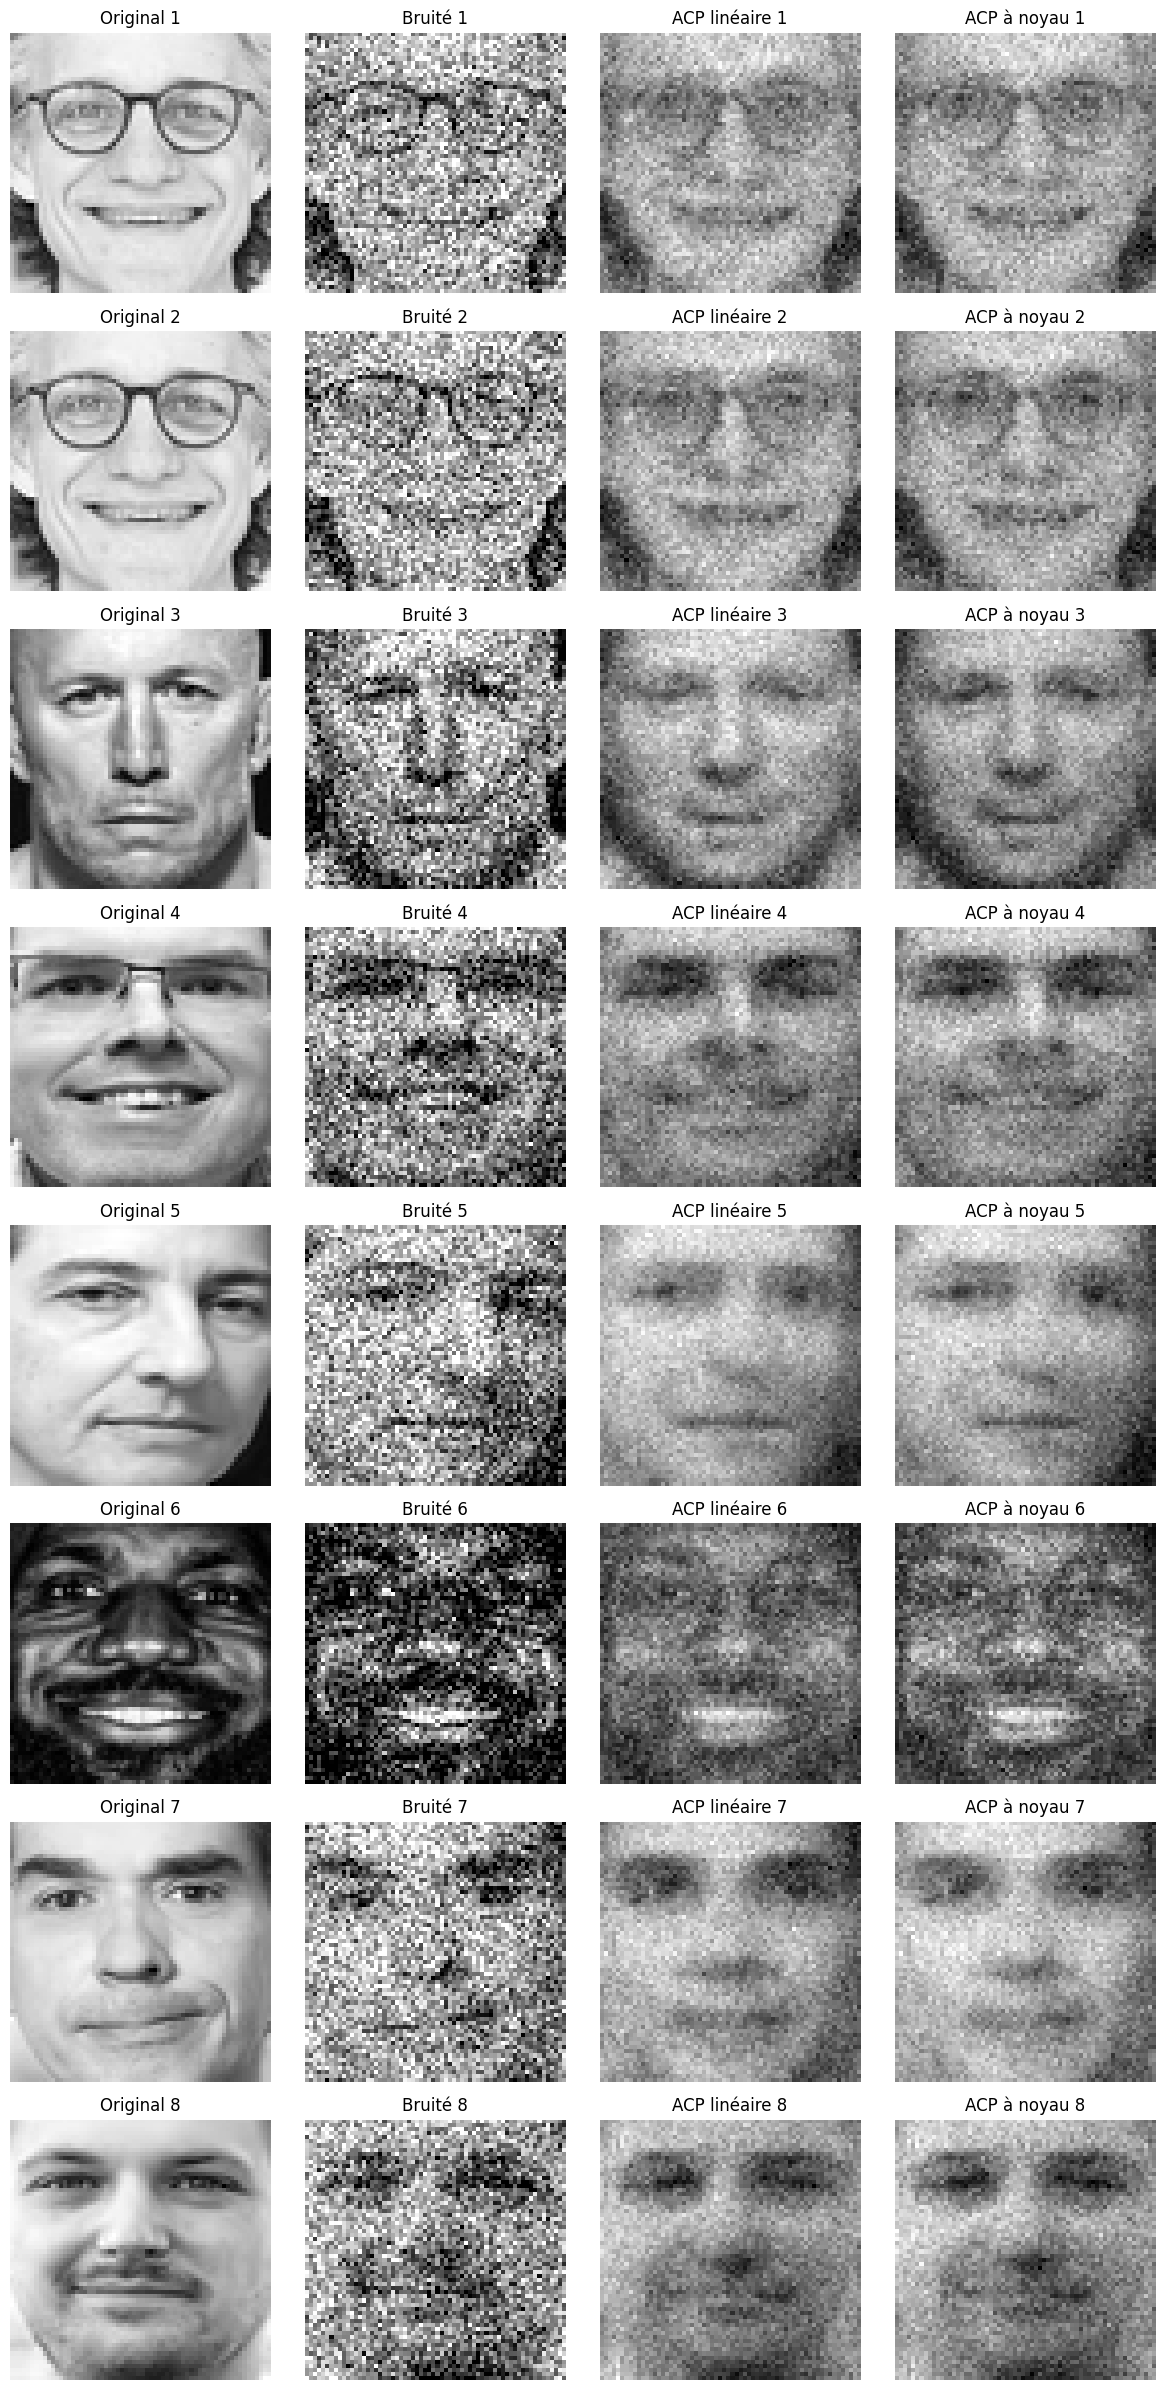

MSE par image (original vs reconstruction) :
Image 1 : PCA MSE = 0.0114, Kernel PCA MSE = 0.0108
Image 2 : PCA MSE = 0.0115, Kernel PCA MSE = 0.0110
Image 3 : PCA MSE = 0.0142, Kernel PCA MSE = 0.0131
Image 4 : PCA MSE = 0.0116, Kernel PCA MSE = 0.0108
Image 5 : PCA MSE = 0.0101, Kernel PCA MSE = 0.0091
Image 6 : PCA MSE = 0.0194, Kernel PCA MSE = 0.0193
Image 7 : PCA MSE = 0.0091, Kernel PCA MSE = 0.0088
Image 8 : PCA MSE = 0.0079, Kernel PCA MSE = 0.0079


In [53]:
# --- 9. Visualisation ---
fig, axes = plt.subplots(n_custom, 4, figsize=(12, 3 * n_custom))
if n_custom == 1:
    axes = axes.reshape(1, -1)

for i in range(n_custom):
    axes[i, 0].imshow(X_specific[i].reshape(64,64), cmap='gray')
    axes[i, 0].set_title(f"Original {i+1}")
    axes[i, 0].axis('off')

    axes[i, 1].imshow(X_specific_noisy[i].reshape(64,64), cmap='gray')
    axes[i, 1].set_title(f"Bruité {i+1}")
    axes[i, 1].axis('off')

    axes[i, 2].imshow(X_specific_pca[i].reshape(64,64), cmap='gray')
    axes[i, 2].set_title(f"ACP linéaire {i+1}")
    axes[i, 2].axis('off')

    axes[i, 3].imshow(X_specific_kpca[i].reshape(64,64), cmap='gray')
    axes[i, 3].set_title(f"ACP à noyau {i+1}")
    axes[i, 3].axis('off')

plt.tight_layout()
plt.show()

# --- 10. Calcul des MSE ---
print("MSE par image (original vs reconstruction) :")
for i in range(n_custom):
    mse_pca = np.mean((X_specific[i] - X_specific_pca[i])**2)
    mse_kpca = np.mean((X_specific[i] - X_specific_kpca[i])**2)
    print(f"Image {i+1} : PCA MSE = {mse_pca:.4f}, Kernel PCA MSE = {mse_kpca:.4f}")

8 images personnalisées seront débruitées.


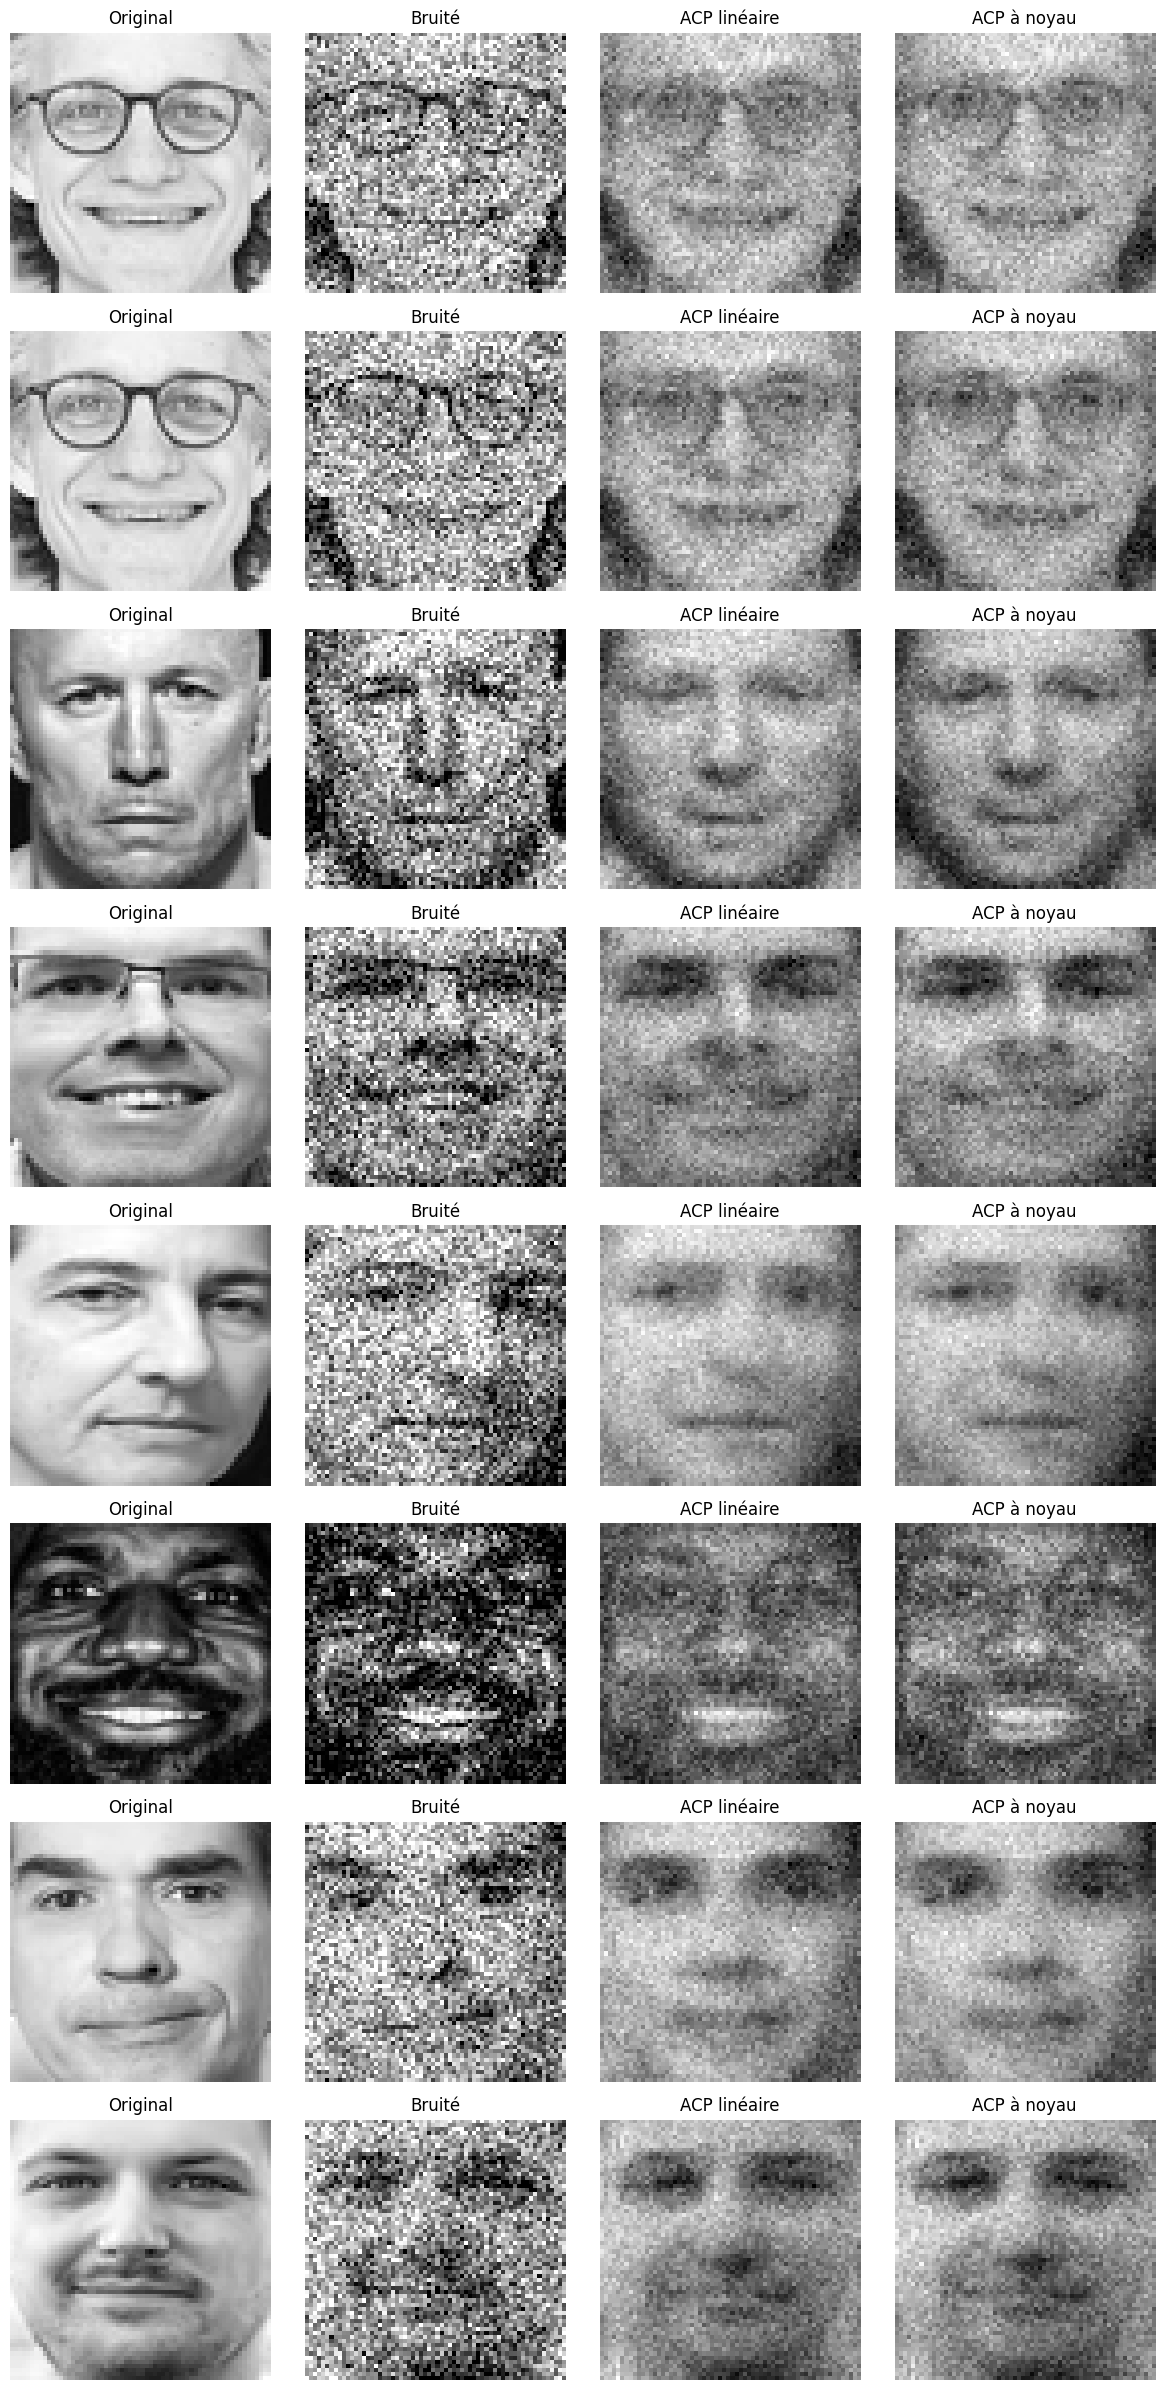


Erreur quadratique moyenne (MSE) :
Image 1 : PCA = 0.0114, Kernel PCA = 0.0108
Image 2 : PCA = 0.0115, Kernel PCA = 0.0111
Image 3 : PCA = 0.0142, Kernel PCA = 0.0134
Image 4 : PCA = 0.0116, Kernel PCA = 0.0110
Image 5 : PCA = 0.0101, Kernel PCA = 0.0092
Image 6 : PCA = 0.0194, Kernel PCA = 0.0201
Image 7 : PCA = 0.0091, Kernel PCA = 0.0088
Image 8 : PCA = 0.0079, Kernel PCA = 0.0079


In [55]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces
from sklearn.decomposition import PCA, KernelPCA
import os
from PIL import Image

# ------------------------------------------------------------
# 1. Chargement de vos images personnalisées
# ------------------------------------------------------------
def load_custom_faces(folder, target_size=(64, 64)):
    X_custom = []
    for f in os.listdir(folder):
        if f.lower().endswith(('.png', '.jpg', '.jpeg')):
            path = os.path.join(folder, f)
            img = Image.open(path).convert('L')
            img = img.resize(target_size, Image.Resampling.LANCZOS)
            arr = np.array(img, dtype=np.float32) / 255.0
            X_custom.append(arr.ravel())
    return np.array(X_custom)

custom_folder = "mes_visages"   # à adapter
X_custom = load_custom_faces(custom_folder)

if len(X_custom) == 0:
    print("Aucune image trouvée. Utilisation d'images Olivetti.")
    X_custom = None

# ------------------------------------------------------------
# 2. Chargement d'Olivetti
# ------------------------------------------------------------
faces = fetch_olivetti_faces(shuffle=True, random_state=42)
X = faces.data   # (400, 4096)

# ------------------------------------------------------------
# 3. Construction de l'ensemble d'entraînement
# ------------------------------------------------------------
# On ajoute vos images à l'entraînement (pour que le modèle les connaisse)
if X_custom is not None:
    X_train = np.vstack([X, X_custom])
else:
    X_train = X

# Images cibles : celles que l'on veut débruiter (vos images, ou quelques Olivetti)
if X_custom is not None:
    X_specific = X_custom
    print(f"{len(X_custom)} images personnalisées seront débruitées.")
else:
    X_specific = X[:5]   # si pas de perso, on prend 5 Olivetti

# Ajout de bruit
rng = np.random.RandomState(0)
noise_std = 0.2

X_train_noisy = X_train + rng.normal(scale=noise_std, size=X_train.shape)
X_specific_noisy = X_specific + rng.normal(scale=noise_std, size=X_specific.shape)

X_train_noisy = np.clip(X_train_noisy, 0, 1)
X_specific_noisy = np.clip(X_specific_noisy, 0, 1)

# ------------------------------------------------------------
# 4. PCA linéaire (référence)
# ------------------------------------------------------------
pca = PCA(n_components=64, random_state=42)
pca.fit(X_train_noisy)

# ------------------------------------------------------------
# 5. Kernel PCA avec les paramètres d'origine (performants)
# ------------------------------------------------------------
kpca = KernelPCA(
    n_components=200,
    kernel='rbf',
    gamma=0.0005,
    fit_inverse_transform=True,
    alpha=0.0001,
    random_state=42
)
kpca.fit(X_train_noisy)

# ------------------------------------------------------------
# 6. Reconstruction des images cibles
# ------------------------------------------------------------
X_specific_pca = pca.inverse_transform(pca.transform(X_specific_noisy))
X_specific_kpca = kpca.inverse_transform(kpca.transform(X_specific_noisy))

# ------------------------------------------------------------
# 7. Visualisation
# ------------------------------------------------------------
n_specific = len(X_specific)
fig, axes = plt.subplots(n_specific, 4, figsize=(12, 3 * n_specific))
if n_specific == 1:
    axes = axes.reshape(1, -1)

for i in range(n_specific):
    axes[i, 0].imshow(X_specific[i].reshape(64, 64), cmap='gray')
    axes[i, 0].set_title("Original")
    axes[i, 0].axis('off')
    
    axes[i, 1].imshow(X_specific_noisy[i].reshape(64, 64), cmap='gray')
    axes[i, 1].set_title("Bruité")
    axes[i, 1].axis('off')
    
    axes[i, 2].imshow(X_specific_pca[i].reshape(64, 64), cmap='gray')
    axes[i, 2].set_title("ACP linéaire")
    axes[i, 2].axis('off')
    
    axes[i, 3].imshow(X_specific_kpca[i].reshape(64, 64), cmap='gray')
    axes[i, 3].set_title("ACP à noyau")
    axes[i, 3].axis('off')

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 8. MSE
# ------------------------------------------------------------
print("\nErreur quadratique moyenne (MSE) :")
for i in range(n_specific):
    mse_pca = np.mean((X_specific[i] - X_specific_pca[i])**2)
    mse_kpca = np.mean((X_specific[i] - X_specific_kpca[i])**2)
    print(f"Image {i+1} : PCA = {mse_pca:.4f}, Kernel PCA = {mse_kpca:.4f}")